# Predicción de desempeño académico SIMCE mediante IDPS

### Problema:
¿Qué tanto  se relacionan los Indicadores de Desarrollo Personal y Social (IDPS) con el rendimiento académico SIMCE de los establecimientos
educacionales en Chile?

### Modelo: Regresión
Se utiliza regresión lineal múltiple para darle un valor numérico al efecto de cada indicador IDPS sobre el puntaje SIMCE (entre 0 y 400) de Matemática y Lectura por establecimiento.

*Para simplificar el modelo en esta primera parte, se realizará solo con el puntaje de Matemática como target (prom_mate2m_rbd), en la segunda parte se hará con el de lectura (prom_lect2m_rbd).*

**Variable objetivo (Y):** Puntaje SIMCE Matemática por establecimiento

**Variables predictoras (X):** ind_am, ind_cc, ind_hv, ind_pf, NSE,
dependencia, ruralidad

**Significados Variables:**

- **ind_am = Autoestima Académica y Motivación:** Índice alto  = colegio con estudiantes que se sienten capaces y motivados
- **ind_cc = Clima de Convivencia Escolar:** Se refiere a cómo se perciben las siguientes variables:
  - Qué tan seguro
  - Qué tan respetuoso
  - Qué tan organizado
 (Indicador más relacionado al bullying de todos)
 - **ind_hv = Hábitos de Vida Saludable:** Mide actitudes relacionadas con el bienestar físico, actividad física y autocuidado
 - **ind_pf = Participación y Formación Ciudadana:** Sentido de pertenencia al colegio y el fomento de valores democráticos y participación estudiantil
 - *Info Extra: todas las variables ind_ van de 0 a 100, donde a mayor número, mejor resultado*

 - **NSE = Nivel Socioeconómico del Establecimiento = cod_grupo:** Se divide en 5 categorías: Bajo, Medio bajo, Medio, Medio alto y Alto
 - **dependencia = Tipo de Establecimiento = cod_depe2** Se divide en: Municipal, Particular, Subvencionado, Particular Pagado o SLEP
 - **ruralidad = Si el establecimiento está en zona urbana o rural = cod_rural_rbd**



### Objetivos del proyecto
1. Cuantificar qué IDPS tiene mayor asociación con el rendimiento SIMCE
2. Determinar si esa relación se mantiene al controlar por NSE
3. Comparar el poder explicativo del modelo entre Matemática y Lectura,
   identificando si los IDPS tienen distinta influencia según la asignatura.

### Metodología: Framework OSEMN
Obtain → Scrub → Explore → Model → iNterpret

------------------

## 1) OBTAIN:

**Fuente:** [Agencia de Calidad de la Educación](https://informacionestadistica.agenciaeducacion.cl/#/bases),
la cual posee registros históricos de establecimientos educacionales chilenos:
- SIMCE
- Indicadores de Desarrollo Personal y Social (IDPS)

**Nota sobre el dataset actual:** el dataset utilizado en esta entrega es una versión preliminar que considera únicamente registros de 2° medio entre los años 2018 y 2024 aproximadamente. El dataset final del proyecto incorporará más información.

In [ ]:
# 1) OBTAIN: Carga y revisión inicial del dataset

from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()  # Sube dataset

df = pd.read_csv("dataset_historico_final.csv")

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Años disponibles: {sorted(df['agno'].unique())}")
print(f"\nPrimeras filas:")
df.head()

Saving dataset_historico_final.csv to dataset_historico_final (1).csv
Dimensiones del dataset: 11663 filas × 11 columnas
Años disponibles: [np.int64(2017), np.int64(2018), np.int64(2022), np.int64(2023)]

Primeras filas:


,rbd,agno,prom_mate2m_rbd,prom_lect2m_rbd,cod_grupo,cod_rural_rbd,cod_depe2,ind_am,ind_cc,ind_hv,ind_pf
0,1,2017,198.0,206.0,Bajo,Urbano,Municipal,72.699036,69.769382,65.950102,74.433735
1,4,2017,274.0,260.0,Medio bajo,Urbano,Municipal,71.817146,72.468397,68.341465,74.127309
2,5,2017,314.0,269.0,Medio,Urbano,Municipal,75.497820,75.865767,60.845889,76.745586
3,7,2017,213.0,226.0,Bajo,Urbano,Municipal,68.986572,72.917178,65.835917,74.826062
4,8,2017,246.0,216.0,Medio bajo,Urbano,Municipal,77.242643,73.806271,65.752104,76.897595


## 2) SCRUB:
En esta sección se realizaron 3 operaciones:
  1) **Estandarizar las variables categóricas:** algunas variables utilizan códigos
   numéricos (1, 2, 3, ...) que no tienen significado real, por lo que se convierten a etiquetas de texto descriptivas para facilitar la interpretación
  2) **Valores Nulos:** Se eliminan las filas con datos nulos (dropna)
  3) **Outliers:** Se aplica IQR (rango intercuartil) sobre los puntajes SIMCE ya que se asume que no hay una distribución normal en los datos


In [ ]:
# Valores ANTES de estandarizar
print("NSE (cod_grupo):", df['cod_grupo'].unique())
print("Dependencia (cod_depe2):", df['cod_depe2'].unique())
print("Ruralidad (cod_rural_rbd):", df['cod_rural_rbd'].unique())

=== VALORES ORIGINALES ===
NSE (cod_grupo): ['Bajo' 'Medio bajo' 'Medio' 'Medio alto' 'Alto']
Dependencia (cod_depe2): ['Municipal' 'Particular subvencionado' 'Particular pagado' 'SLEP']
Ruralidad (cod_rural_rbd): ['Urbano' 'Rural']


In [ ]:
# 2) SCRUB: Limpieza de dataset


nse_map = {'1.0': 'Bajo', '2.0': 'Medio bajo', '3.0': 'Medio',
           '4.0': 'Medio alto', '5.0': 'Alto'}
depe_map = {'1': 'Municipal', '2': 'Particular subvencionado',
            '3': 'Particular pagado', '4': 'SLEP'}
rural_map = {'1': 'Urbano', '2': 'Rural'}

df['cod_grupo']     = df['cod_grupo'].replace(nse_map)
df['cod_depe2']     = df['cod_depe2'].replace(depe_map)
df['cod_rural_rbd'] = df['cod_rural_rbd'].replace(rural_map)

print("Resultados de la estandarización de las var. categóricas:")
print("Categorías NSE:", df['cod_grupo'].unique())
print("Categorías dependencia:", df['cod_depe2'].unique())
print("Categorías ruralidad:", df['cod_rural_rbd'].unique())

#nulos
print(f"\nValores nulos por columna:")
print(df.isnull().sum())
df = df.dropna()
print(f"Filas después de dropna: {len(df)}")

# Detección y eliminación de Outliers en SIMCE
for col in ['prom_mate2m_rbd', 'prom_lect2m_rbd']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    antes = len(df)
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    print(f"Outliers eliminados en {col}: {antes - len(df)}")

print(f"\nDataset final: {df.shape[0]} filas")

Resultados de la estandarización de las var. categóricas:
Categorías NSE: ['Bajo' 'Medio bajo' 'Medio' 'Medio alto' 'Alto']
Categorías dependencia: ['Municipal' 'Particular subvencionado' 'Particular pagado' 'SLEP']
Categorías ruralidad: ['Urbano' 'Rural']

Valores nulos por columna:
rbd                0
agno               0
prom_mate2m_rbd    0
prom_lect2m_rbd    0
cod_grupo          0
cod_rural_rbd      0
cod_depe2          0
ind_am             0
ind_cc             0
ind_hv             0
ind_pf             0
dtype: int64
Filas después de dropna: 11625
Outliers eliminados en prom_mate2m_rbd: 0
Outliers eliminados en prom_lect2m_rbd: 0

Dataset final: 11625 filas


## Resultados del SCRUB
- No se encontraron valores nulos en el dataset
- La detección de outliers usando IQR no eliminó registros, ya que el dataset de prueba fue procesado previamente
  - Sin embargo, como a futuro se tiene pensado utilizar un dataset más grande, se aplica IQR igualmente
- Las variables categóricas NSE, dependenciay ruralidad pasaron de códigos numéricos a etiquetas de texto descriptivas

## 3) EXPLORE:

Se explora la distribución de las variables objetivo y su relación  con los predictores, a través de estadísticas descriptivas y de visualización

In [ ]:
# 3) EXPLORE: Estadísticas descriptivas

import matplotlib.pyplot as plt
import seaborn as sns

print(" -- Estadísticas descriptivas --")
cols_interes = ['prom_mate2m_rbd', 'prom_lect2m_rbd',
                'ind_am', 'ind_cc', 'ind_hv', 'ind_pf']
print(df[cols_interes].describe().round(2))

 -- Estadísticas descriptivas --
       prom_mate2m_rbd  prom_lect2m_rbd    ind_am    ind_cc    ind_hv  \
count         11625.00         11625.00  11625.00  11625.00  11625.00   
mean            259.24           248.92     74.41     75.67     70.45   
std              40.76            26.04      3.84      4.89      5.54   
min             149.00           173.00     54.50     51.06     41.67   
25%             227.00           229.00     72.00     72.33     67.00   
50%             252.00           247.00     74.12     75.66     70.53   
75%             287.00           268.00     76.85     78.93     74.00   
max             377.00           326.00     92.13     95.00     93.20   

         ind_pf  
count  11625.00  
mean      77.54  
std        5.22  
min       38.84  
25%       74.12  
50%       77.65  
75%       81.00  
max       97.50  


##Distribución de puntajes SIMCE de Matemática

A continuación se visualiza la distribución de los puntajes SIMCE de Matemática por establecimiento educacional.

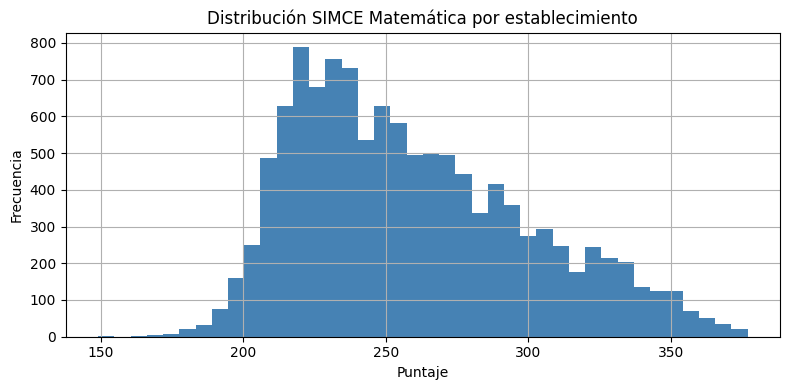

In [ ]:
# 3.1) EXPLORE: Distribución SIMCE Matemáticas

fig, ax = plt.subplots(figsize=(8, 4))
df['prom_mate2m_rbd'].hist(bins=40, ax=ax, color='steelblue')
ax.set_title("Distribución SIMCE Matemática por establecimiento")
ax.set_xlabel("Puntaje")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

##Puntaje SIMCE según nivel socioeconómico (NSE)

El siguiente gráfico permite comparar la distribución de puntajes SIMCE de Matemática entre distintos niveles socioeconómicos.

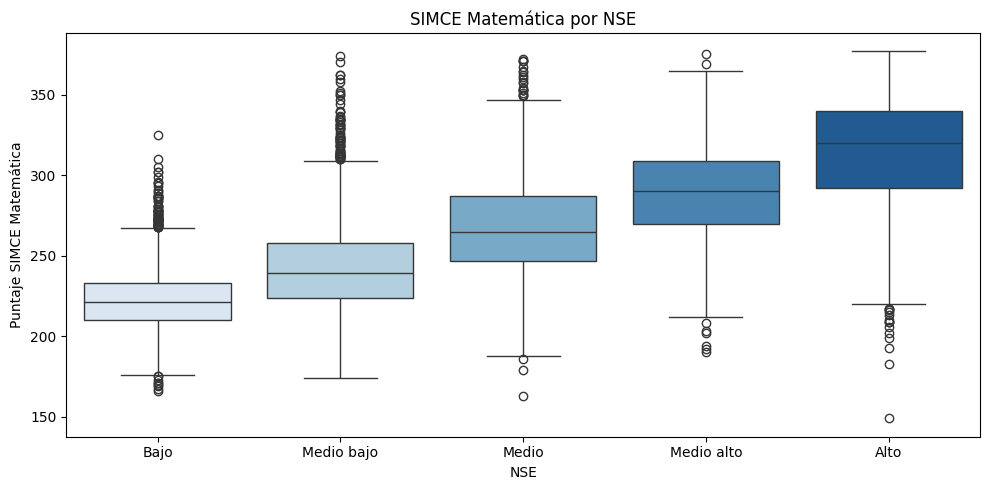

In [ ]:
# 3.2) EXPLORE: SIMCE Matemática por NSE

orden_nse = ['Bajo', 'Medio bajo', 'Medio', 'Medio alto', 'Alto']
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='cod_grupo', y='prom_mate2m_rbd',
            order=orden_nse, ax=ax, palette='Blues',
            hue='cod_grupo', legend=False)
ax.set_title("SIMCE Matemática por NSE")
ax.set_xlabel("NSE")
ax.set_ylabel("Puntaje SIMCE Matemática")
plt.tight_layout()
plt.show()

##Puntaje SIMCE según dependencia administrativa

Esta visualización permite analizar diferencias en el rendimiento académico según el tipo de establecimiento educacional.

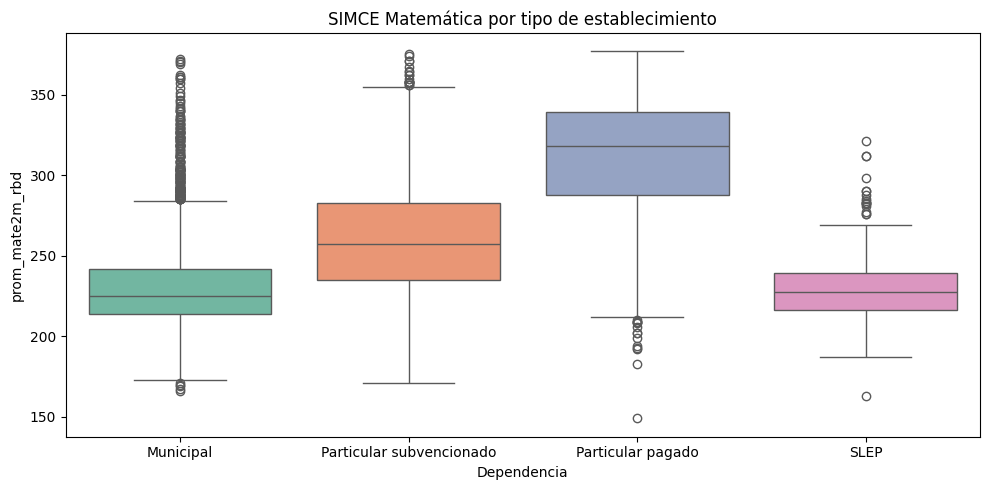

In [ ]:
# 3.3) EXPLORE: SIMCE Matemática por dependencia

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='cod_depe2', y='prom_mate2m_rbd',
            palette='Set2', ax=ax,
            hue='cod_depe2', legend=False)
ax.set_title("SIMCE Matemática por tipo de establecimiento")
ax.set_xlabel("Dependencia")
plt.tight_layout()
plt.show()


##Matriz de correlaciones

La matriz de correlación permite observar la intensidad y dirección de las relaciones lineales entre las variables IDPS y los puntajes SIMCE.

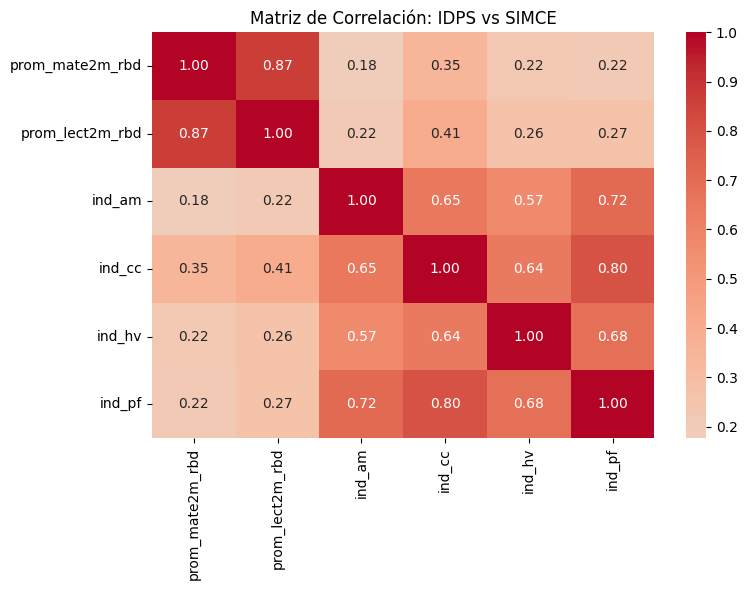

In [ ]:
# 3.4) EXPLORE: Matriz de Correlaciones

corr = df[cols_interes].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlación: IDPS vs SIMCE")
plt.tight_layout()
plt.show()

##Relación entre indicadores IDPS y SIMCE Matemática

Los siguientes gráficos de dispersión permiten visualizar la relación entre cada indicador IDPS y el puntaje SIMCE de Matemática.

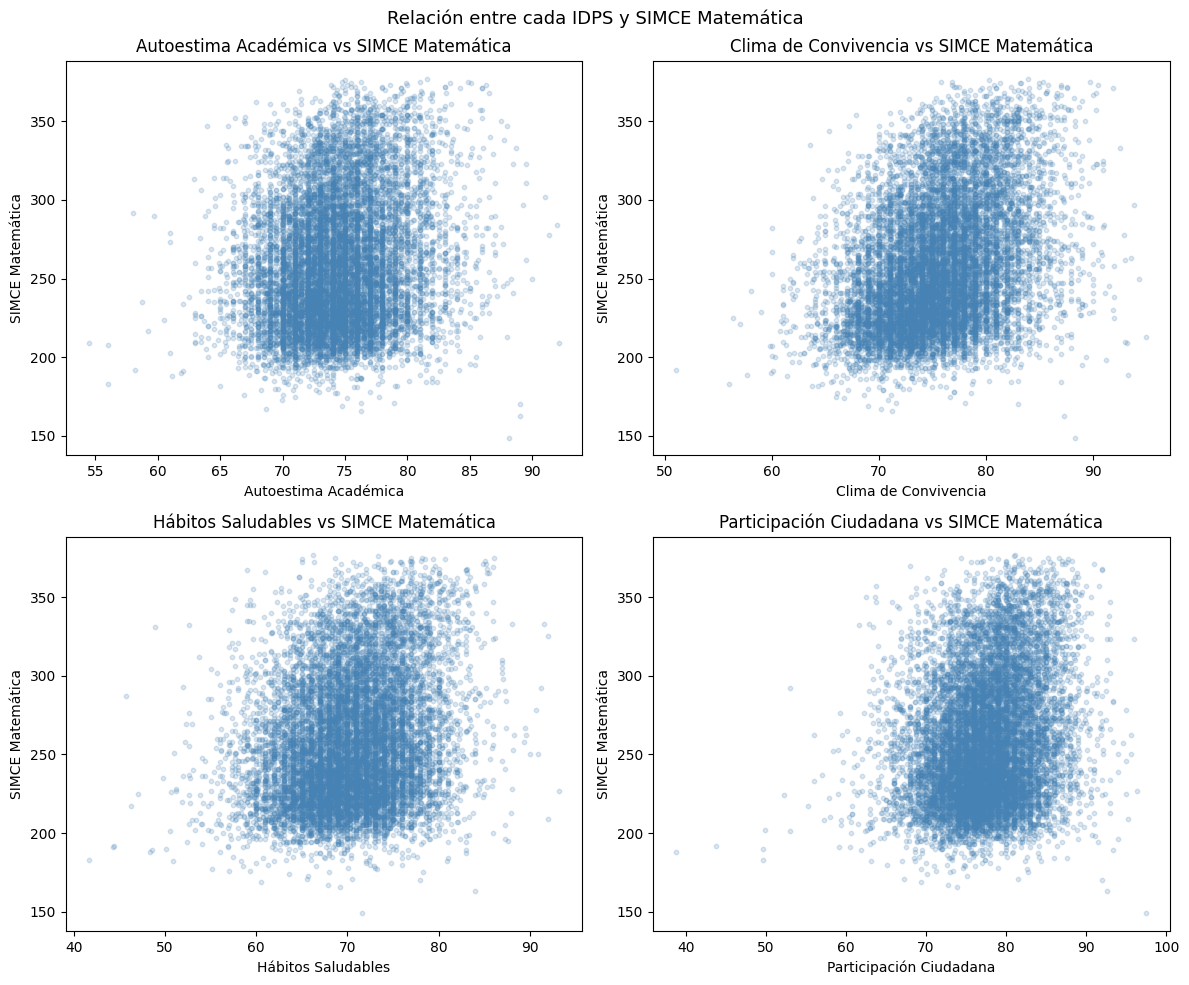

In [ ]:
# 3.5) EXPLORE: Scatter IDPS vs SIMCE Matemática

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
idps = [('ind_am', 'Autoestima Académica'),
        ('ind_cc', 'Clima de Convivencia'),
        ('ind_hv', 'Hábitos Saludables'),
        ('ind_pf', 'Participación Ciudadana')]
for ax, (col, nombre) in zip(axes.flatten(), idps):
    ax.scatter(df[col], df['prom_mate2m_rbd'], alpha=0.2, s=10, color='steelblue')
    ax.set_xlabel(nombre)
    ax.set_ylabel("SIMCE Matemática")
    ax.set_title(f"{nombre} vs SIMCE Matemática")
plt.suptitle("Relación entre cada IDPS y SIMCE Matemática", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusiones Análisis Exploratorio:

- El NSE muestra una relación progresiva y clara con el SIMCE, donde a mayor nivel socioeconómico, mayor puntaje
- Los colegios particulares pagados obtienen puntajes más altos que los municipales y SLEP, los que se comportan de forma similar, mientras que los particulares subencionados quedan en medio
- Matriz de Correlación:
  - Los puntajes de Matemática y Lectura están fuertemente correlacionados entre sí (0.87)
  - El **ind_cc** (Clima de Convivencia) tiene la correlación más fuerte con el SIMCE (0.35 Matemática)
  - El **ind_am** (Autoestima Académico) tiene la correlación más débil con el SIMCE (0.18 Matemática)
  - Los cuatro IDPS están altamente correlacionados entre sí (0.57 a 0.80), esto indicaría multicolinealidad y puede afectar la interpretación individual de cada coeficiente en el modelo

- IDPS vs SIMCE Matemáticas:
  - **ind_cc** (Clima de Convivencia) muestra la tendencia positiva más visible,
  consistente con su correlación más alta (0.35).
  - **ind_am** (Autoestima Académica) presenta la mayor dispersión y la tendencia
  más débil, lo que confirma su baja correlación con el SIMCE (0.18).
  - En todos los gráficos la nube de puntos es amplia, lo que indica que ningún IDPS por sí solo explica el rendimiento. Esto quiere decir que su poder explicativo aparece al combinarlos junto a las variables de contexto en el modelo de regresión.

##4. Modelamiento predictivo

En esta sección se implementa un modelo de regresión lineal múltiple para predecir el puntaje SIMCE de Matemática.

El modelo considera:

*   Variables numéricas asociadas a los indicadores IDPS.
*   Variables categóricas asociadas al contexto escolar.
*   Estandarización de variables numéricas.
*   Codificación One-Hot para variables categóricas.

Además, se utiliza validación cruzada para evaluar la estabilidad del modelo

In [ ]:
# 4) MODEL: Regresión Lineal Múltiple - Matemáticas

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definir variables
target = "prom_mate2m_rbd"

features_num = ["ind_am", "ind_cc", "ind_hv", "ind_pf"]
features_cat = ["cod_grupo", "cod_rural_rbd", "cod_depe2"]

X = df[features_num + features_cat]
y = df[target]

# Train/Test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} registros | Test: {len(X_test)} registros")

# Pipeline de preprocesamiento + modelo
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Entrenamiento
model.fit(X_train, y_train)

# Predicciones y métricas
y_pred = model.predict(X_test)
# MSE: No tiene sentido utilizarlo en el contexto de puntajes SIMCE (pts^2)
# MAPE: En este contexto no hay un cero natural, por lo que no aplica bien
## No hay cero natural pq -> un puntaje de 200 no significa "no hay conocimiento"
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n  RESULTADOS DEL MODELO: \n")

print(f"  MAE:  {mae:.2f}  puntos promedio de error")
print(f"  RMSE: {rmse:.2f}  error cuadrático medio")
print(f"  R²:   {r2:.3f}   varianza explicada por el modelo")

# Validación cruzada (5 folds)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"\nValidación cruzada R² (5 folds): {cv_scores.round(3)}")
print(f"R² promedio CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Train: 9300 registros | Test: 2325 registros

  RESULTADOS DEL MODELO: 

  MAE:  19.64  puntos promedio de error
  RMSE: 25.81  error cuadrático medio
  R²:   0.592   varianza explicada por el modelo

Validación cruzada R² (5 folds): [0.658 0.614 0.543 0.553 0.606]
R² promedio CV: 0.595 ± 0.042


### Interpretación preliminar
Un MAE de 19.64 significa que, en promedio, las predicciones del modelo se equivocan aproximadamente en 20 puntos respecto al valor real. Esta métrica es fácil de interpretar porque expresa directamente el error promedio en la misma escala del problema.

Un RMSE de 25.81 implica que los errores grandes tienen un impacto considerable en el modelo. Como el RMSE penaliza más las diferencias elevadas entre valores reales y predichos, el hecho de que sea notablemente mayor que el MAE sugiere que existen algunos casos donde el modelo falla más de lo normal, generando predicciones bastante alejadas del valor real.

Un R² de 0.592 indica que el modelo explica el 59.2% de la variabilidad en los
puntajes SIMCE entre establecimientos. El enfoque principal de las
siguientes iteraciones será mejorar este valor incorporando interacciones
entre NSE e IDPS.

##Comparación entre valores reales y predichos

El siguiente gráfico permite evaluar visualmente la capacidad predictiva del modelo comparando los valores reales con las predicciones obtenidas.

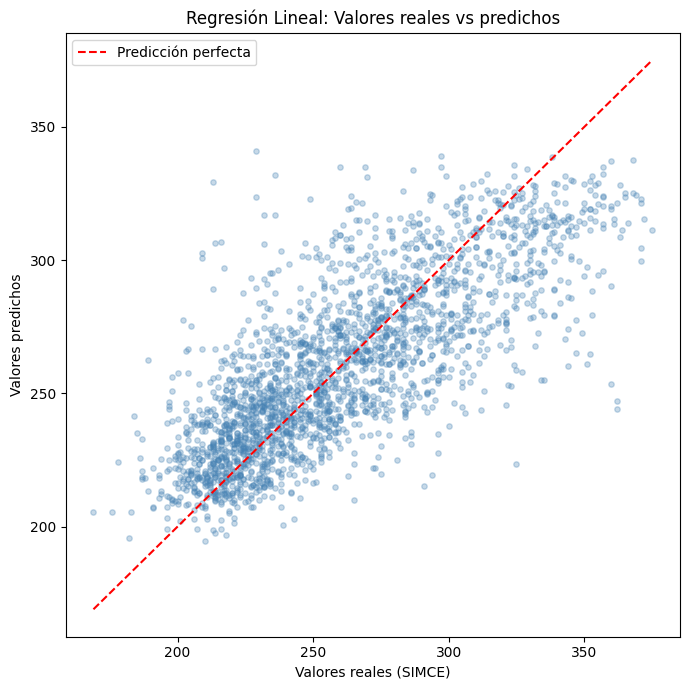

In [ ]:
# 5) iNTERPRETER: Gráfico Real vs Predicho - Matemáticas

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=15, color='steelblue')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')
plt.xlabel("Valores reales (SIMCE)")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal: Valores reales vs predichos")
plt.legend()
plt.tight_layout()
plt.show()

##Distribución de residuos

La distribución de residuos permite evaluar si los errores del modelo se encuentran centrados en torno a cero y si presentan un comportamiento relativamente simétrico.

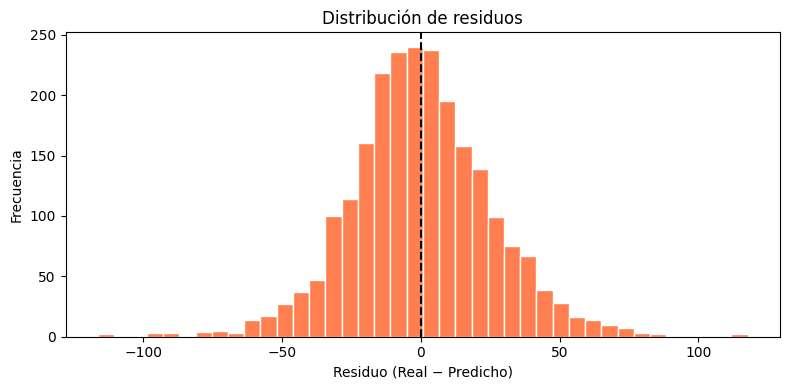

In [ ]:
# 5.1) iNTERPRETER: Distribución de Residuos - Matemáticas

residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40, color='coral', edgecolor='white')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Residuo (Real − Predicho)")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")
plt.tight_layout()
plt.show()

##Importancia de variables

Finalmente, se analizan los coeficientes del modelo para identificar cuáles variables presentan mayor influencia sobre el rendimiento SIMCE de Matemática.

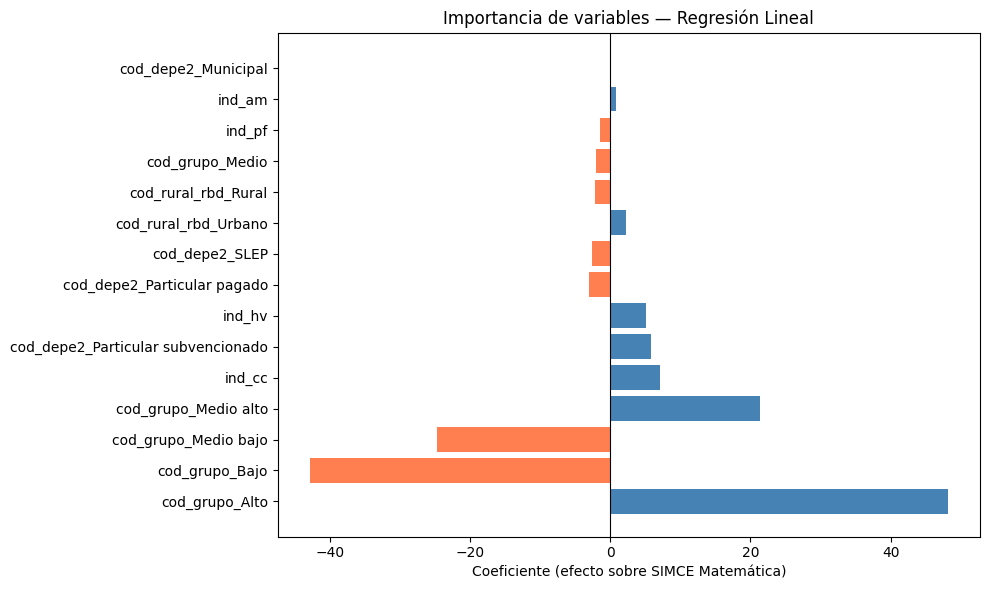


=== Top 5 variables con mayor efecto ===
            Variable  Coeficiente
      cod_grupo_Alto    48.189973
      cod_grupo_Bajo   -42.871765
cod_grupo_Medio bajo   -24.695700
cod_grupo_Medio alto    21.341152
              ind_cc     7.126222


In [ ]:
# 5.2) iNTERPRETER: Importancia de Variables - Matemáticas

feature_names = (
    model.named_steps['preprocessor']
    .named_transformers_['num']
    .get_feature_names_out(features_num).tolist() +
    model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(features_cat).tolist()
)

coefs = model.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'Variable': feature_names, 'Coeficiente': coefs})
coef_df = coef_df.reindex(coef_df['Coeficiente'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Coeficiente (efecto sobre SIMCE Matemática)")
plt.title("Importancia de variables — Regresión Lineal")
plt.tight_layout()
plt.show()

print("\n Top 5 variables con mayor efecto")
print(coef_df.head(5).to_string(index=False))

---------


# Análisis Lectura (prom_lect2m_rbd)

El siguiente análisis replica el pipelin anterior, pero utilizando el puntaje SIMCE de Lectura como variable objetivo, para comparar si los IPDS tienen la misma influencia en ambas asignaturas

##Distribución de puntajes SIMCE de Lenguaje

A continuación, tal como se llevo a cabo con los resultados en matematica, se visualiza la distribución de los puntajes SIMCE de Lneguaje por establecimiento educacional.

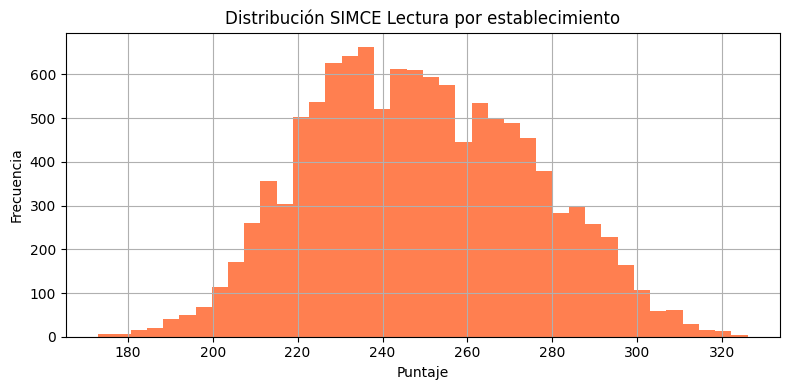

In [ ]:
# 6) EXPLORE: Distribución SIMCE Lectura

fig, ax = plt.subplots(figsize=(8, 4))
df['prom_lect2m_rbd'].hist(bins=40, ax=ax, color='coral')
ax.set_title("Distribución SIMCE Lectura por establecimiento")
ax.set_xlabel("Puntaje")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

##Puntaje SIMCE según nivel socioeconómico (NSE)

El siguiente gráfico permite comparar la distribución de puntajes SIMCE de Lenguaje entre distintos niveles socioeconómicos. Se muestra que el NSE si tiene correlación al puntaje obtenido en SIMCE, evidenciando que, con un NSE alto, se tiende a puntajes mas altos obtenidos.

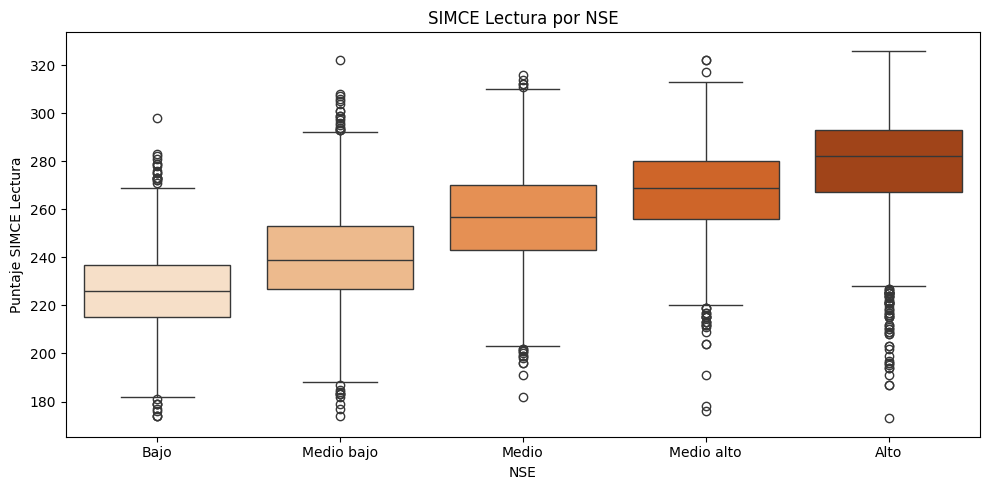

In [ ]:
# 6.1) EXPLORE: SIMCE Lectura por NSE

orden_nse = ['Bajo', 'Medio bajo', 'Medio', 'Medio alto', 'Alto']
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='cod_grupo', y='prom_lect2m_rbd',
            order=orden_nse, ax=ax, palette='Oranges',
            hue='cod_grupo', legend=False)
ax.set_title("SIMCE Lectura por NSE")
ax.set_xlabel("NSE")
ax.set_ylabel("Puntaje SIMCE Lectura")
plt.tight_layout()
plt.show()

##Puntaje SIMCE según dependencia administrativa

Esta visualización permite analizar diferencias en el rendimiento académico según el tipo de establecimiento educacional. Se observan las diferencias de putnaje entre distinto tipo de establecimiento.

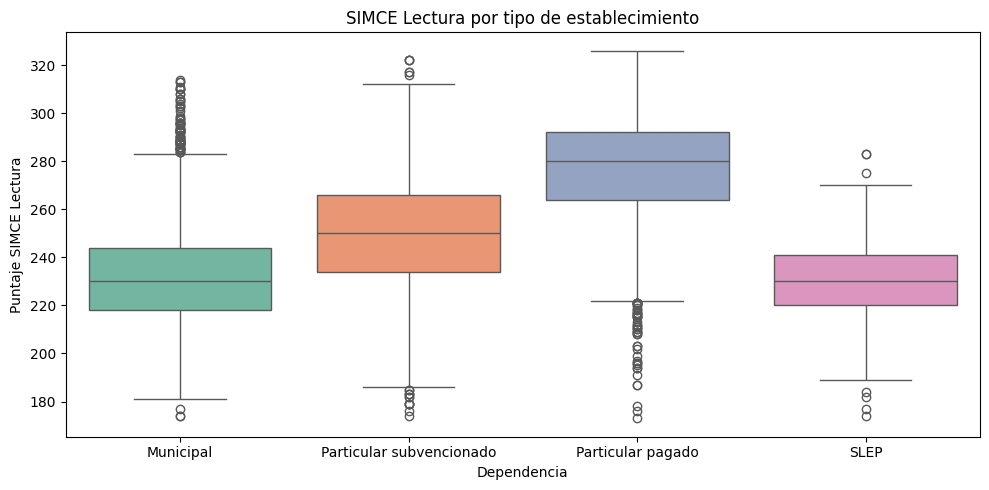

In [ ]:
# 6.2) EXPLORE: SIMCE Lectura por dependencia

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='cod_depe2', y='prom_lect2m_rbd',
            palette='Set2', ax=ax,
            hue='cod_depe2', legend=False)
ax.set_title("SIMCE Lectura por tipo de establecimiento")
ax.set_xlabel("Dependencia")
ax.set_ylabel("Puntaje SIMCE Lectura")
plt.tight_layout()
plt.show()

##Relación entre indicadores IDPS y SIMCE Lenguaje

Los siguientes gráficos de dispersión permiten visualizar la relación entre cada indicador IDPS y el puntaje SIMCE de Lenguaje.

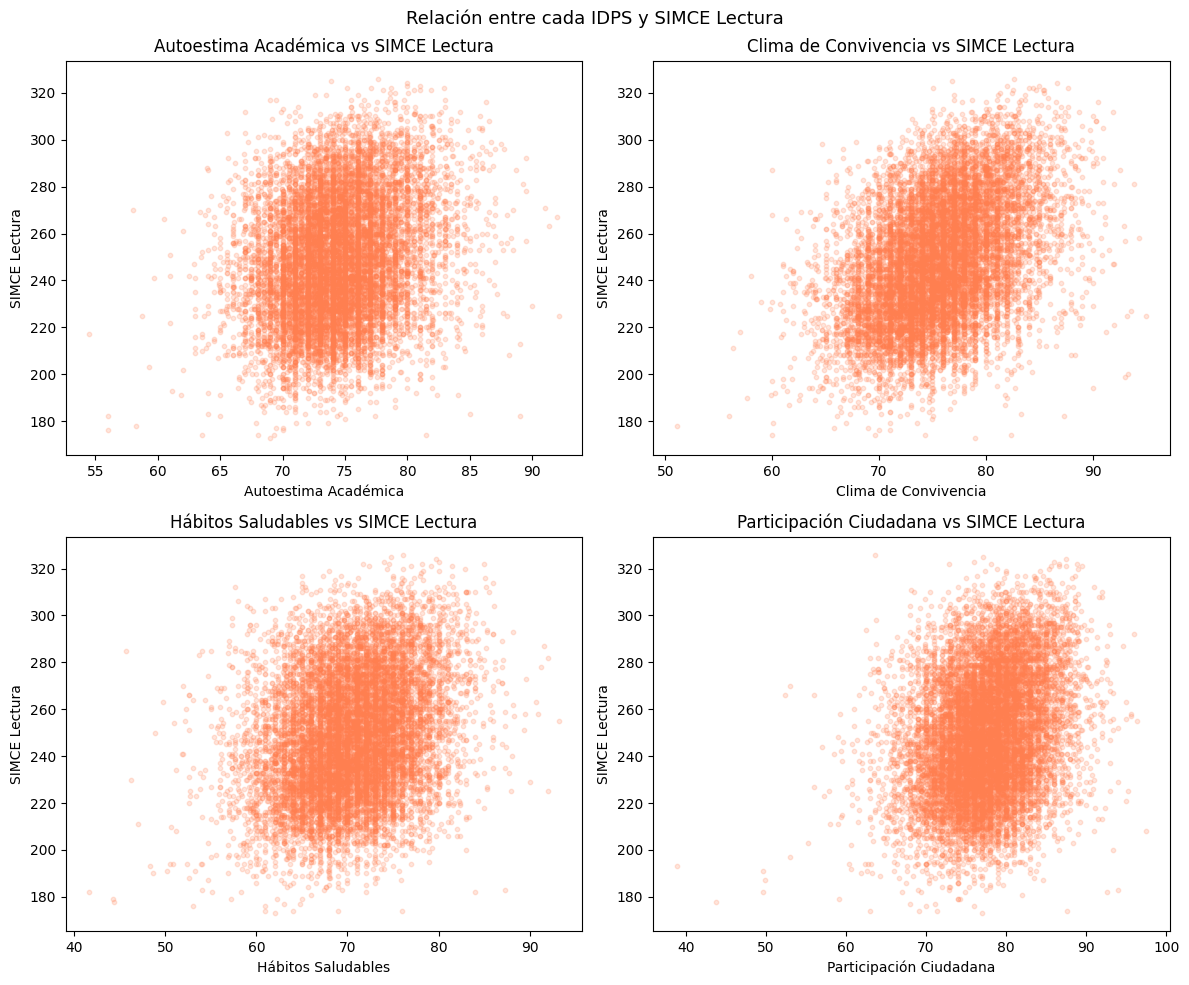

In [ ]:
# 6.3) EXPLORE: Scatter IDPS vs SIMCE Lectura

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
idps = [('ind_am', 'Autoestima Académica'),
        ('ind_cc', 'Clima de Convivencia'),
        ('ind_hv', 'Hábitos Saludables'),
        ('ind_pf', 'Participación Ciudadana')]
for ax, (col, nombre) in zip(axes.flatten(), idps):
    ax.scatter(df[col], df['prom_lect2m_rbd'], alpha=0.2, s=10, color='coral')
    ax.set_xlabel(nombre)
    ax.set_ylabel("SIMCE Lectura")
    ax.set_title(f"{nombre} vs SIMCE Lectura")
plt.suptitle("Relación entre cada IDPS y SIMCE Lectura", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusiones Análisis Exploratorio:

- El NSE muestra una relacion directa, mientras mayor nivel socioeconomico, los puntajes tienden a ser mas altos, al igual que el tipo de colegio (subencionado, particular, etc)

- Matriz de Correlación:
  - Los puntajes de Lectura están fuertemente correlacionados entre sí (0.87), lo que indica que los colegios que rinden bien en un SIMCE, también lo hacen en el otro
  - El **ind_cc** (Clima de Convivencia) tiene la correlación más fuerte con el SIMCE (0.41 Lectura)
  - El **ind_am** (Autoestima Académico) tiene la correlación más débil con el SIMCE (0.22 Lectura)
  - Todos los IDPS están correlacionados más fuerte con el SIMCE de Lectura que con el de Matemática, lo que sugiere los factores socioemocionales tienen mayor influencia en Lectura
- IDPS vs SIMCE Lenguaje:
  - **ind_pc** (Participación ciudadana) muestra la tendencia positiva más visible, consistente con su correlación más alta.
  - **ind_am** (Autoestima Académica) presenta la mayor dispersión y la tendencia
  más débil, lo que confirma su baja correlación con el SIMCE (0.18).
  - Tal como en matematica, todos los gráficos la nube de puntos es amplia, lo que indica que ningún IDPS por sí solo explica el rendimiento.

In [ ]:
# 7) MODEL: Regresión Lineal Múltiple - Lectura

target_lect = "prom_lect2m_rbd"

X_lect = df[features_num + features_cat]
y_lect = df[target_lect]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_lect, y_lect, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train_l)} registros | Test: {len(X_test_l)} registros")

model_lect = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model_lect.fit(X_train_l, y_train_l)
y_pred_l = model_lect.predict(X_test_l)

mae_l  = mean_absolute_error(y_test_l, y_pred_l)
rmse_l = np.sqrt(mean_squared_error(y_test_l, y_pred_l))
r2_l   = r2_score(y_test_l, y_pred_l)

print("\n  RESULTADOS DEL MODELO LECTURA: \n")
print(f"  MAE:  {mae_l:.2f}  puntos promedio de error")
print(f"  RMSE: {rmse_l:.2f}  error cuadrático medio")
print(f"  R²:   {r2_l:.3f}   varianza explicada por el modelo")

cv_scores_l = cross_val_score(model_lect, X_lect, y_lect, cv=5, scoring='r2')
print(f"\nValidación cruzada R² (5 folds): {cv_scores_l.round(3)}")
print(f"R² promedio CV: {cv_scores_l.mean():.3f} ± {cv_scores_l.std():.3f}")


Train: 9300 registros | Test: 2325 registros

  RESULTADOS DEL MODELO LECTURA: 

  MAE:  13.19  puntos promedio de error
  RMSE: 17.09  error cuadrático medio
  R²:   0.557   varianza explicada por el modelo

Validación cruzada R² (5 folds): [0.576 0.563 0.501 0.523 0.572]
R² promedio CV: 0.547 ± 0.030


##Interpretacion preliminar

Un MAE de 13.19, tal como la interpretacion anterior, indica que las predicciones presentan un error promedio cercano a 13 puntos respecto al valor real.

Un RMSE de 17.09 sugiere que, aunque existen algunos errores más grandes, estos no son excesivamente altos. La diferencia moderada entre RMSE y MAE indica que el modelo mantiene una estabilidad razonable

Un R² de 0.557 significa que el modelo logra explicar aproximadamente el 55.7% de la variabilidad presente en los datos. Esto implica que más de la mitad del comportamiento de la variable objetivo puede ser interpretado a partir de las variables incluidas en el modelo, mientras que el resto depende de factores externos

##Comparación entre valores reales y predichos

El siguiente gráfico permite evaluar visualmente la capacidad predictiva del modelo comparando los valores reales con las predicciones obtenidas.

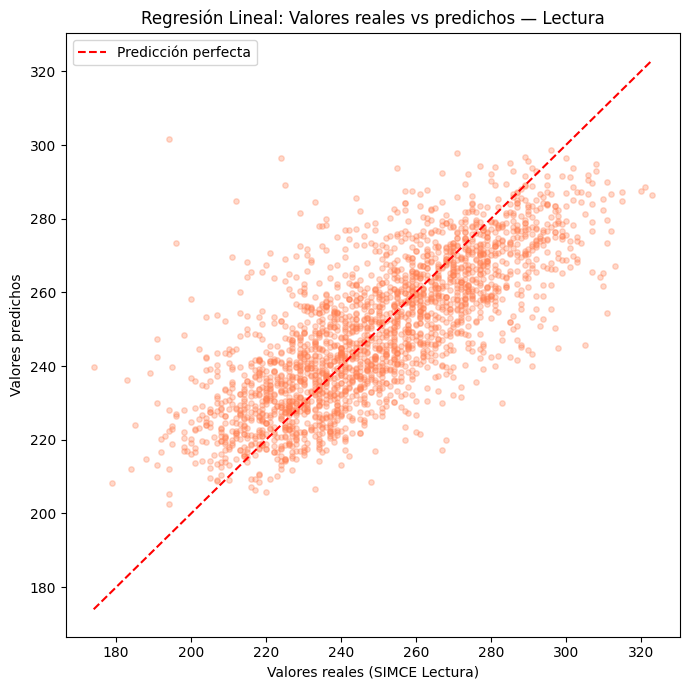

In [ ]:
# 8) iNTERPRET: Valores reales vs predichos - Lectura

plt.figure(figsize=(7, 7))
plt.scatter(y_test_l, y_pred_l, alpha=0.3, s=15, color='coral')
min_val = min(y_test_l.min(), y_pred_l.min())
max_val = max(y_test_l.max(), y_pred_l.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')
plt.xlabel("Valores reales (SIMCE Lectura)")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal: Valores reales vs predichos — Lectura")
plt.legend()
plt.tight_layout()
plt.show()

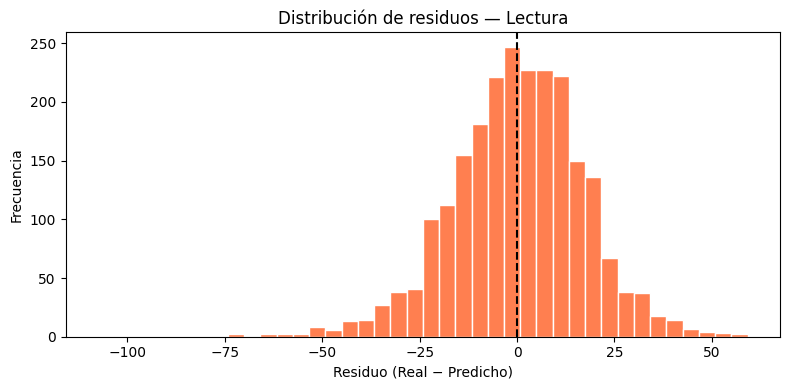

In [ ]:
# 8.1) iNTERPRET: Distribución de residuos - Lectura

residuals_l = y_test_l - y_pred_l
plt.figure(figsize=(8, 4))
plt.hist(residuals_l, bins=40, color='coral', edgecolor='white')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Residuo (Real − Predicho)")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos — Lectura")
plt.tight_layout()
plt.show()

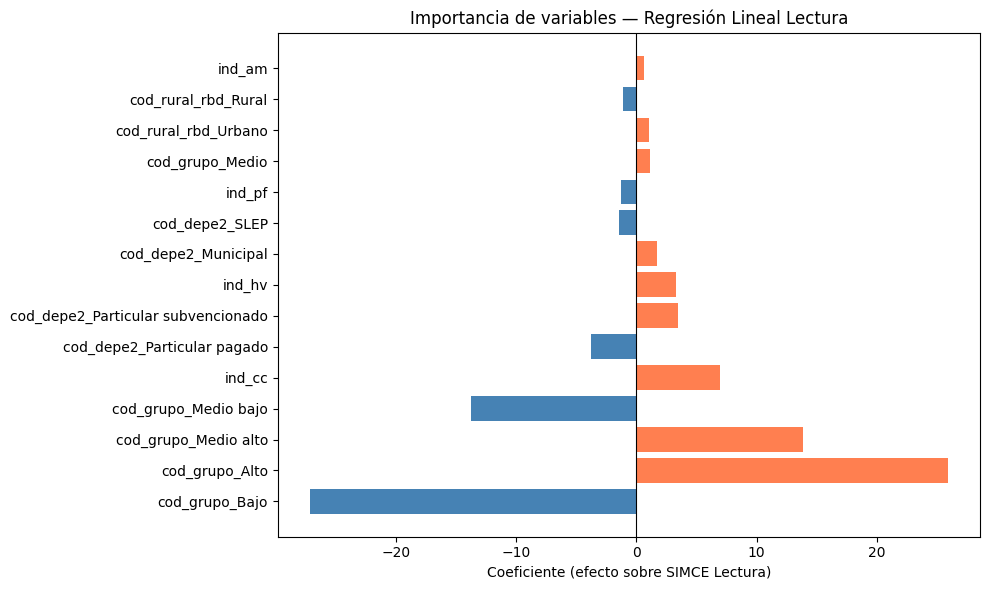


 Top 5 variables con mayor efecto
            Variable  Coeficiente
      cod_grupo_Bajo   -27.155710
      cod_grupo_Alto    25.926121
cod_grupo_Medio alto    13.872671
cod_grupo_Medio bajo   -13.749207
              ind_cc     6.970621


In [ ]:
 # 8.2) iNTERPRET: Importancia de variables — Lectura

feature_names_l = (
    model_lect.named_steps['preprocessor']
    .named_transformers_['num']
    .get_feature_names_out(features_num).tolist() +
    model_lect.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(features_cat).tolist()
)

coefs_l = model_lect.named_steps['regressor'].coef_
coef_df_l = pd.DataFrame({'Variable': feature_names_l, 'Coeficiente': coefs_l})
coef_df_l = coef_df_l.reindex(coef_df_l['Coeficiente'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
colors_l = ['coral' if c > 0 else 'steelblue' for c in coef_df_l['Coeficiente']]
plt.barh(coef_df_l['Variable'], coef_df_l['Coeficiente'], color=colors_l)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Coeficiente (efecto sobre SIMCE Lectura)")
plt.title("Importancia de variables — Regresión Lineal Lectura")
plt.tight_layout()
plt.show()

print("\n Top 5 variables con mayor efecto")
print(coef_df_l.head(5).to_string(index=False))

----------------

## Comparación Matemáticas vs Lectura
A continuación, se muestra una comparación de los resultados de las materias escogidas, evaluando la eficacia del modelo.


In [ ]:
print("=" * 45)
print("   COMPARACIÓN DE MODELOS")
print("=" * 45)
print(f"{'Métrica':<10} {'Matemática':>15} {'Lectura':>15}")
print("-" * 45)
print(f"{'MAE':<10} {mae:>15.2f} {mae_l:>15.2f}")
print(f"{'RMSE':<10} {rmse:>15.2f} {rmse_l:>15.2f}")
print(f"{'R²':<10} {r2:>15.3f} {r2_l:>15.3f}")
print(f"{'R² CV':<10} {cv_scores.mean():>15.3f} {cv_scores_l.mean():>15.3f}")
print("=" * 45)

   COMPARACIÓN DE MODELOS
Métrica         Matemática         Lectura
---------------------------------------------
MAE                  19.64           13.19
RMSE                 25.81           17.09
R²                   0.592           0.557
R² CV                0.595           0.547


##Conclusión
- De los IDPS, *ind_cc* (Clima de Convivencia) es el indicador con mayor
  influencia sobre el SIMCE en ambas asignaturas, lo que sugiere que intervenir
  en el ambiente escolar puede tener impacto en el rendimiento académico.
- El modelo explica el **59.2% Matemática** y el **55.7%
  en Lectura**, lo que indica un ajuste moderado con espacio de mejora.
- Los IDPS tienen mayor poder explicativo en Lectura que en Matemática,
  según lo reflejan las correlaciones más altas en esa asignatura.